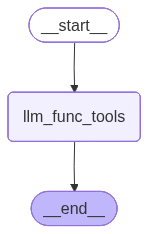

In [2]:
def add(a:int,b:int)->int:
    """Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import display,Image
from langgraph.graph.message import add_messages

llm = ChatOpenAI(model="gpt-4o-mini")

initial_message = [AIMessage(content="Hi How can I help you",name="llmmodel")]
initial_message.append(HumanMessage(content="I want to learn programming",name="Harika"))

ai_message = AIMessage(content="Which PL you want to learn",name="llmmodel")

add_messages(initial_message,ai_message)

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]


llm_tool = llm.bind_tools([add])

def llm_func_tools(state:State):
    return {"messages":[llm_tool.invoke(state['messages'])]}

builder = StateGraph(State)

builder.add_node('llm_func_tools',llm_func_tools)
builder.add_edge(START,'llm_func_tools')
builder.add_edge('llm_func_tools',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [3]:
messages = graph.invoke({"messages" : "What is 2+2"})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_7DorXr40ErmgzbxdhJA24PnX)
 Call ID: call_7DorXr40ErmgzbxdhJA24PnX
  Args:
    a: 2
    b: 2


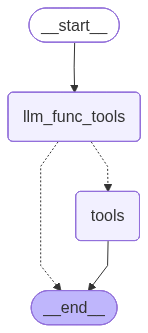

In [6]:
from langgraph.prebuilt import ToolNode,tools_condition

builder = StateGraph(State)

tools = [add]

builder.add_node('llm_func_tools',llm_func_tools)
builder.add_node('tools',ToolNode(tools))

builder.add_edge(START,'llm_func_tools')
builder.add_conditional_edges('llm_func_tools',# If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END
                              tools_condition)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [9]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":"What is 2+2"})
for message in messages['messages']:
    message.pretty_print()


================================ Human Message =================================

What is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_GUTayFKfjZ5T7obW5XSSONQW)
 Call ID: call_GUTayFKfjZ5T7obW5XSSONQW
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
